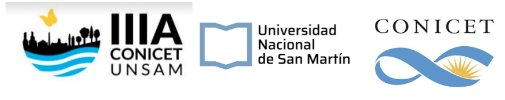  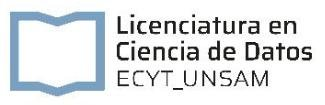

---

# NB01 — Imágenes como arrays y lectura satelital

Lo que veremos en esta notebook:

- [x] Estructura de archivos y directorios del curso
- [x] Imágenes monocromáticas expresadas como arrays de NumPy
- [x] Representación en niveles de gris y resolución espacial
- [x] El histograma como descripción de una imagen
- [x] Imágenes RGB: tres matrices apiladas y el modelo aditivo del color
- [x] Lectura de imágenes satelitales con Rasterio
- [x] Propiedades de un archivo raster: dimensiones, tipo de dato, CRS, geotransformación
- [x] Corrección atmosférica: qué es y por qué importa
- [x] Ecualización por percentil
- [x] Primer vistazo al área de estudio: recorte Moreno / Reconquista
---

### Objetivos de la notebook

Al terminar esta clase esperamos que puedas:

- Entender qué es una imagen digital y cómo se representa como una matriz numérica.
- Leer y explorar las propiedades básicas de una imagen satelital usando Rasterio.
- Visualizar bandas individuales con distintas opciones de escalado.
- Generar composiciones RGB y el histograma de una banda.

### Datos con los que trabajaremos

- `homero.jpg` y `homero_color.jpg` — imágenes sencillas sin geografía para introducir los conceptos.
- `data/raw_data/satelital/S2_moreno_B02B03B04B08_2026feb.tif` — recorte Sentinel-2 del área de estudio (bandas Azul, Verde, Rojo y NIR, resolución 10 m, tile T21HUB, nivel L2A).

### Área de estudio

A lo largo del curso trabajaremos sobre los partidos de **Moreno, Merlo, General Rodríguez y Marcos Paz**, en el borde oeste del Área Metropolitana de Buenos Aires. Esta zona presenta un gradiente notable: desde el tejido urbano consolidado hasta el periurbano, los campos y los humedales de la cuenca del Río Reconquista, donde se encuentra el Dique Roggero. Es un territorio en transformación activa, con preguntas ambientales y sociales que guiarán el hilo del curso.

En esta primera clase lo vamos a ver por primera vez desde el satélite.

---
# 0. Estructura de archivos del curso

Antes de escribir una línea de código, conviene entender cómo vamos a organizar los archivos durante todo el cuatrimestre. Una buena estructura de directorios es parte del trabajo: facilita reproducir el análisis, encontrar lo que se necesita y no sobreescribir datos originales por error.

```
curso_ADE/
├── ade_tools.py               ← biblioteca del curso (crece con cada clase)
├── data/
│   ├── raw_data/              ← datos originales. NUNCA se modifican ni se sobreescriben.
│   │   ├── satelital/         ← imágenes GeoTIFF y ZIP de Sentinel-2 y Landsat
│   │   ├── vectorial/         ← shapefiles, GeoJSON, GeoPackage
│   │   ├── tablas/            ← archivos CSV (censo, SMN, etc.)
│   │   └── auxiliar/          ← imágenes de ejemplo no satelitales (homero.jpg, etc.)
│   ├── proc/                  ← productos intermedios del procesamiento
│   └── out/                   ← salidas finales: GeoTIFFs procesados, figuras, mapas
└── notebooks/
    ├── NB01_...ipynb
    ├── NB02_...ipynb
    └── ...
```

**Regla fundamental:** `raw_data/` es de solo lectura. Todo lo que nuestro código *genera* va a `proc/` (si es un paso intermedio) o a `out/` (si es un resultado final que queremos conservar o mostrar). Esto garantiza que siempre podamos volver a los datos originales.

**`ade_tools.py`** es la biblioteca del curso. Empieza casi vacía y va creciendo clase a clase: cada vez que definamos una función suficientemente útil y general, la vamos a incorporar ahí para poder importarla en las notebooks siguientes. Al final del cuatrimestre van a tener una biblioteca de herramientas de análisis espacial que construyeron ustedes mismos.

### `ade_tools.py` al inicio del curso

```python
"""
ade_tools.py
Herramientas para el curso Análisis de Datos Espaciales (UNSAM).
Este módulo crece a lo largo del cuatrimestre.
"""
import numpy as np
import matplotlib.pyplot as plt
import rasterio
```

A lo largo de esta notebook vamos a definir las primeras funciones que luego van a vivir ahí.

---
# 1. Bibliotecas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import rasterio

# Rutas base
RAW  = 'data/raw_data/'
PROC = 'data/proc/'
OUT  = 'data/out/'

---
# 2. Imágenes como arrays

Una imagen digital no es más que una matriz numérica. Cada elemento de la matriz —llamado **píxel** (*picture element*)— almacena un valor que representa la intensidad de luz en esa posición.

Empecemos con el ejemplo más simple: una matriz de 16×16 donde los valores van de 0 (negro) a 255 (blanco).

In [ ]:
array = np.arange(256, dtype=np.uint8).reshape(16, 16)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(array, cmap='Greys_r')
axes[0].set_title('Imagen: gradiente de 0 a 255')
for (i, j), z in np.ndenumerate(array):
    axes[0].text(j, i, z, ha='center', va='center', fontsize=6)

axes[1].hist(array.ravel(), bins=32, color='steelblue', edgecolor='white')
axes[1].set_title('Histograma')
axes[1].set_xlabel('Valor de píxel')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 2.1 Una imagen real: Homero en escala de grises

In [ ]:
imagen_gris = plt.imread(RAW + 'auxiliar/homero.jpg')

print('Tipo de objeto  :', type(imagen_gris))
print('Dimensiones     :', imagen_gris.shape, '  →  (filas, columnas)')
print('Tipo de dato    :', imagen_gris.dtype)
print('Rango de valores:', imagen_gris.min(), '-', imagen_gris.max())

plt.figure(figsize=(5, 5))
plt.imshow(imagen_gris, cmap='Greys_r')
plt.title('Homero en escala de grises')
plt.axis('off')
plt.show()

## 2.2 Niveles de gris y resolución espacial

### Profundidad de bits

La **profundidad de bits** define cuántos tonos distintos puede representar cada píxel. Una imagen de **8 bits** tiene 2⁸ = 256 niveles posibles (de 0 a 255). Las imágenes satelitales suelen trabajar con **16 bits** (hasta 65 536 niveles), lo que permite capturar diferencias sutiles de reflectancia.

### Resolución espacial

La **resolución espacial** es el tamaño real del terreno que representa cada píxel. Degradarla artificialmente muestra qué información se pierde:

In [ ]:
img_pil = Image.open(RAW + 'auxiliar/homero.jpg')
factores = [1, 4, 16]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, factor in zip(axes, factores):
    nueva_dim = (img_pil.size[0] // factor, img_pil.size[1] // factor)
    img_reducida = np.array(img_pil.resize(nueva_dim, Image.NEAREST))
    ax.imshow(img_reducida, cmap='Greys_r')
    ax.set_title(f'Factor 1/{factor}  ({img_reducida.shape[1]} × {img_reducida.shape[0]} px)')
    ax.axis('off')

plt.suptitle('Efecto de reducir la resolución espacial', y=1.01)
plt.tight_layout()
plt.show()

## 2.3 El histograma como descripción de una imagen

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(imagen_gris, cmap='Greys_r')
axes[0].set_title('Imagen')
axes[0].axis('off')

axes[1].hist(imagen_gris.ravel(), bins=64, color='#555', edgecolor='none')
axes[1].axvline(imagen_gris.mean(), color='tomato', linestyle='--',
                label=f'Media: {imagen_gris.mean():.1f}')
axes[1].set_title('Histograma')
axes[1].set_xlabel('Valor de píxel  (0 = negro, 255 = blanco)')
axes[1].set_ylabel('Número de píxeles')
axes[1].legend()

plt.tight_layout()
plt.show()

### Ejercicio guiado 2.1

Calculá para la imagen de Homero: media, mediana, desvío estándar, percentil 5 y percentil 95.

¿A qué región de la imagen creés que corresponden los valores bajos (cerca de 0)? ¿Y los valores altos?

In [ ]:
# Tu código acá


## 2.4 Imágenes RGB: tres matrices apiladas

Una imagen en color no es una sola matriz sino **tres matrices apiladas**: una para el canal rojo (R), una para el verde (G) y una para el azul (B).

### El modelo aditivo del color

El modelo RGB es **aditivo**: combinando luz de los tres colores primarios en distintas proporciones se obtiene cualquier color del espectro visible. La siguiente imagen lo ilustra — notá cómo la superposición de R+G+B al máximo produce blanco:

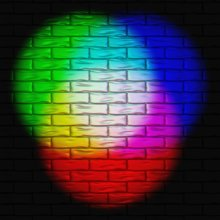

Cuando leemos una imagen color con matplotlib obtenemos un array de dimensiones `(filas, columnas, 3)`, con las bandas en el orden R, G, B:

In [ ]:
imagen_color = plt.imread(RAW + 'auxiliar/homero_color.jpg')

print('Dimensiones:', imagen_color.shape, '  →  (filas, columnas, bandas)')
print('Tipo de dato:', imagen_color.dtype)

### Descomposición en canales

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
# Original
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(imagen_color)
ax.set_title('Original (RGB combinado)')
ax.axis('off')
plt.show()

cmap_r = LinearSegmentedColormap.from_list('', ['black', '#FF0000'])
cmap_g = LinearSegmentedColormap.from_list('', ['black', '#00FF00'])
cmap_b = LinearSegmentedColormap.from_list('', ['black', '#0000FF'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (nombre, cmap, ax) in enumerate(zip(['Rojo (R)', 'Verde (G)', 'Azul (B)'],
                                            [cmap_r, cmap_g, cmap_b], axes)):
    ax.imshow(imagen_color[:, :, i], cmap=cmap, vmin=0, vmax=255)
    ax.set_title(nombre)
    ax.axis('off')
plt.suptitle('Cada canal con su colormap', y=1.01)
plt.show()

Observá que el fondo blanco de Homero tiene valores altos en los **tres** canales simultáneamente (blanco = R+G+B al máximo), mientras que la piel amarilla tiene R y G altos pero B bajo.

### Ejercicio guiado 2.2

Generá una versión de Homero donde los canales Rojo y Azul estén intercambiados. ¿Qué color aparece en lugar del amarillo de su piel? Usá el diagrama del modelo aditivo para interpretar el resultado.

*Tip:* `array.copy()` crea una copia independiente del array. Asignar con `b = a` no copia, solo crea un segundo nombre para el mismo objeto en memoria.

In [ ]:
# Tu código acá


---
# 3. Imágenes satelitales con Rasterio

Las imágenes que vimos hasta acá son archivos comunes (`.jpg`). Las imágenes satelitales son diferentes:

- Tienen **georeferenciación**: cada píxel tiene coordenadas geográficas reales.
- Están en formato **GeoTIFF** (`.tif`), que almacena los datos y su metadata geoespacial juntos.
- Pueden tener muchas bandas de diferente tipo, enteros de 16 bits, de punto flotante, etc.
- Los valores representan mediciones físicas de **reflectancia**, no tonos de color.

**Rasterio** es la biblioteca central para leer, escribir y procesar estos archivos.

## 3.1 Lectura y propiedades de un archivo raster

In [ ]:
fn = RAW + 'satelital/S2_moreno_B02B03B04B08_2026feb.tif'

with rasterio.open(fn) as src:
    print('=== Propiedades de la imagen ===')
    print(f'  Driver           : {src.driver}')
    print(f'  Dimensiones      : {src.width} columnas × {src.height} filas')
    print(f'  Número de bandas : {src.count}')
    print(f'  Tipo de dato     : {src.dtypes[0]}')
    print(f'  CRS              : {src.crs}')
    print(f'  Geotransformación: {src.transform}')
    print(f'  Bounds           : {src.bounds}')
    print(f'  NoData           : {src.nodata}')

- **CRS** (*Coordinate Reference System*): sistema de referencia de coordenadas. Describe la proyección usada. Lo veremos en profundidad en NB02.
- **Geotransformación**: relación matemática entre posición en la matriz (fila, columna) y coordenadas reales en el mapa.
- **Bounds**: extensión espacial de la imagen (coordenadas mínimas y máximas en X e Y).
- **NoData**: valor reservado para píxeles sin datos válidos.

> **Una nota sobre CRS:** para representar la superficie curva de la Tierra en una imagen plana necesitamos una **proyección**. Cuando en NB02 veamos que Sentinel-2 y Landsat no se superponen directamente, la causa es que pueden venir en proyecciones distintas.

## 3.2 Leer los datos como array

In [ ]:
with rasterio.open(fn) as src:
    imagen = src.read()      # shape: (bandas, filas, columnas)
    perfil = src.profile

print('Shape:', imagen.shape, '  →  (bandas, filas, columnas)')
print('Tipo de dato:', imagen.dtype)
print()
print('Estadísticas por banda:')
nombres_bandas = ['Azul B02', 'Verde B03', 'Rojo B04', 'NIR B08']
for i, nombre in enumerate(nombres_bandas):
    b = imagen[i]
    print(f'  {nombre}: min={b.min():6d}  max={b.max():6d}  '
          f'media={b.mean():7.1f}  p5={int(np.percentile(b,5)):6d}  p95={int(np.percentile(b,95)):6d}')

La convención de Rasterio es **(bandas, filas, columnas)**, diferente a matplotlib que espera **(filas, columnas, bandas)** para RGB. Convertimos solo cuando necesitamos visualizar.

En las imágenes Sentinel-2 los valores son de tipo `uint16` en el orden de los miles: son **reflectancias de superficie escaladas por 10 000**. Una reflectancia de 0.30 (30%) se almacena como 3000. Cuando calculemos índices en NB02 aplicaremos ese factor. Imágenes de otros sensores pueden tener otra convención para convertir el valor que descargamos a un valor con sentido físico: la reflectancia.

## 3.3 Una nota sobre corrección atmosférica

Los satélites no miden directamente la reflectancia de la superficie: miden la energía que llega al sensor después de atravesar la atmósfera dos veces. La **corrección atmosférica** elimina esa distorsión.

Los productos Sentinel-2 vienen en dos niveles:

| Nivel | Descripción |
|---|---|
| **L1C** | Reflectancia en el tope de la atmósfera (TOA) — sin corrección |
| **L2A** | Reflectancia de superficie (BOA) — con corrección atmosférica aplicada |

En este curso siempre usamos productos **L2A**. Cuando descarguen imágenes de [Copernicus Data Space](https://dataspace.copernicus.eu) asegúrense de seleccionar ese nivel.

---
# 4. Visualización de imágenes satelitales

## 4.1 Una banda sin ecualización

In [ ]:
banda_roja = imagen[2]   # índice 2 = Rojo (B04)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(banda_roja, cmap='Greys_r')
axes[0].set_title('Banda Roja (B04) — sin ecualización')
axes[0].axis('off')

axes[1].hist(banda_roja.ravel(), bins=100, color='tomato', edgecolor='none')
axes[1].set_title('Histograma de la banda roja')
axes[1].set_xlabel('Valor de reflectancia (× 10 000)')
axes[1].set_ylabel('Número de píxeles')

plt.tight_layout()
plt.show()

La imagen se ve oscura porque los valores se concentran en un rango pequeño comparado con el máximo posible de `uint16` (65 535). Para visualizar bien necesitamos **ecualizar**.

## 4.2 Ecualización por percentil

In [ ]:
def escalar(array, p=2, nodata=None):
    """
    Escala un array 2D al rango [0, 1] usando los percentiles p y 100-p.
    Los valores extremos se recortan (clip) a 0 y 1 respectivamente.

    Parámetros
    ----------
    array  : np.ndarray 2D
    p      : float — percentil de corte inferior (default 2)
    nodata : valor a ignorar en el cálculo (default None)

    Retorna
    -------
    np.ndarray 2D de float64 en [0, 1]
    """
    datos = array[array != nodata].ravel() if nodata is not None else array.ravel()
    vmin  = np.nanpercentile(datos, p)
    vmax  = np.nanpercentile(datos, 100 - p)
    return np.clip((array - vmin) / (vmax - vmin), 0, 1)


percentiles = [0, 2, 5]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, p in zip(axes, percentiles):
    ax.imshow(escalar(banda_roja, p=p), cmap='Greys_r', vmin=0, vmax=1)
    ax.set_title(f'Ecualización {p}%')
    ax.axis('off')

plt.suptitle('Efecto del percentil de ecualización — Banda Roja (B04)')
plt.tight_layout()
plt.show()

El percentil del **2%** es el estándar habitual en teledetección: descarta los valores extremos más relevantes sin perder contraste en las zonas de interés. Lo vamos a usar como valor por defecto en todo el curso.

---
> **`escalar()` → `ade_tools.py`**
>
> Esta función va a ser útil en todas las notebooks siguientes. Al final de esta clase la incorporamos a `ade_tools.py`.
> A partir de NB02 la importamos con `from ade_tools import escalar`.

---
# 5. Primer vistazo al área de estudio

El archivo `S2_moreno_B02B03B04B08_2026feb.tif` contiene 4 bandas del Sentinel-2 sobre el área Moreno / Reconquista:

| Índice Python | Banda S2 | Longitud de onda | Región espectral |
|---|---|---|---|
| 0 | B02 | 490 nm | Azul |
| 1 | B03 | 560 nm | Verde |
| 2 | B04 | 665 nm | Rojo |
| 3 | B08 | 842 nm | Infrarrojo cercano (NIR) |

Resolución espacial: **10 m**. Nivel de procesamiento: **L2A**.

In [ ]:
with rasterio.open(fn) as src:
    imagen = src.read()

print(f'Recorte: {imagen.shape[2]*10/1000:.0f} km de ancho × {imagen.shape[1]*10/1000:.0f} km de alto')
print(f'Total de píxeles por banda: {imagen.shape[1]*imagen.shape[2]:,}')

## 5.1 Las cuatro bandas en escala de grises

In [ ]:
nombres_bandas = ['Azul (B02)', 'Verde (B03)', 'Rojo (B04)', 'NIR (B08)']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for i, (ax, nombre) in enumerate(zip(axes.ravel(), nombres_bandas)):
    ax.imshow(escalar(imagen[i], p=2), cmap='Greys_r', vmin=0, vmax=1)
    ax.set_title(nombre, fontsize=13)
    ax.axis('off')

plt.suptitle('Sentinel-2 — Recorte Moreno / Reconquista\nEcualización 2%', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

El NIR (infrarrojo cercano) merece atención especial: las zonas con **vegetación activa** aparecen muy brillantes en NIR y relativamente oscuras en Rojo. Esta diferencia es la base del NDVI que calcularemos en NB02.

## 5.2 Composición en color natural

In [ ]:
def componer_rgb(imagen, bandas, pmax=98, pmin=0):
    """
    Compone una imagen RGB usando una escala COMÚN para las tres bandas.

    vmin = 0 por defecto (reflectancias no son negativas).
    vmax = percentil p del máximo entre los percentiles de cada banda.

    Al usar el mismo vmax para los tres canales se preserva el balance
    de color real: una banda con poca reflectancia no se amplifica
    artificialmente respecto a las demás.

    Parámetros
    ----------
    imagen : np.ndarray (bandas, filas, columnas)
    bandas : lista de tres índices [idx_R, idx_G, idx_B]
    p      : percentil para calcular vmax (default 98)
    vmin   : valor mínimo de recorte (default 0)
    """
    vmax = max(np.nanpercentile(imagen[b], pmax) for b in bandas)
    vmin = min(np.nanpercentile(imagen[b], pmin) for b in bandas)
    return np.stack([np.clip((imagen[b] - vmin) / (vmax - vmin), 0, 1)
                     for b in bandas], axis=-1)


def ecualizar_rgb(imagen, bandas, p=2):
    """
    Compone una imagen RGB ecualizando CADA BANDA INDEPENDIENTEMENTE.

    Útil cuando se combinan bandas con rangos muy distintos, por ejemplo
    al mezclar bandas de reflectancia con índices espectrales.

    Parámetros
    ----------
    imagen : np.ndarray (bandas, filas, columnas)
    bandas : lista de tres índices [idx_R, idx_G, idx_B]
    p      : percentil de ecualización por banda (default 2)
    """
    return np.stack([escalar(imagen[b], p=p) for b in bandas], axis=-1)


# ── Comparación de las dos estrategias ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

rgb_comun = componer_rgb(imagen, bandas=[2, 1, 0], pmax=98)
axes[0].imshow(rgb_comun)
axes[0].set_title('Escala común entre bandas\n(componer_rgb, pmax=98)', fontsize=12)
axes[0].axis('off')

rgb_ecual = ecualizar_rgb(imagen, bandas=[2, 1, 0])
axes[1].imshow(rgb_ecual)
axes[1].set_title('Ecualización independiente por banda\n(ecualizar_rgb, p=2)', fontsize=12)
axes[1].axis('off')

plt.suptitle('Dos estrategias de composición RGB — Recorte Moreno / Reconquista', fontsize=13)
plt.tight_layout()
plt.show()

En la composición en color natural podés empezar a identificar:

- La **mancha urbana** de Moreno: tonos grises y beige.
- Las zonas de **vegetación**: distintos tonos de verde.
- El **Dique Roggero** y el Río Reconquista: tonos oscuros azulados.
- Los **campos** al oeste: parcelas con distintos tonos según cobertura.

La comparación entre las dos estrategias es instructiva:
- La **escala común** (`componer_rgb`) preserva las relaciones reales de reflectancia entre canales: una banda con poca señal se ve oscura, como en la realidad. Es la composición correcta para interpretar colores.
- La **ecualización independiente** (`ecualizar_rgb`) maximiza el contraste de cada canal por separado. Útil para resaltar detalles, pero distorsiona el color real. Es la opción cuando se mezclan bandas con rangos muy distintos, como al combinar un índice (rango [-1,1]) con una banda de reflectancia (rango [0, 10000]).

A lo largo del curso vamos a aprender a cuantificar y clasificar cada uno de los elementos del territorio.

---
> **`componer_rgb()`, `ecualizar_rgb()` → `ade_tools.py`**

---
# Ejercicios de entrega

Resolvé los siguientes ejercicios en esta misma notebook, debajo de cada consigna. Agregá las celdas de código que necesites y, cuando se pida una interpretación, usá una celda markdown. Entregá la notebook completa con todas las celdas ejecutadas.

---

## Ejercicio 1 — Exploración de bandas

a) Para cada una de las 4 bandas del recorte Sentinel-2, calculá: media, desvío estándar, percentil 5 y percentil 95. Mostrá los resultados en una tabla o gráfico comparativo.

b) ¿Qué banda tiene el mayor rango entre percentil 5 y percentil 95? ¿Tiene sentido ese resultado según el comportamiento espectral de la vegetación?

---

## Ejercicio 2 — Composiciones RGB

Generá las siguientes tres composiciones y mostralas en una sola figura con títulos:

**a) Color natural:** R=B04, G=B03, B=B02.

**b) Falso color infrarrojo:** R=B08 (NIR), G=B04 (Rojo), B=B03 (Verde). La vegetación activa aparece en tonos rojos intensos.

**c) Composición libre:** cualquier combinación de las 4 bandas. En una celda markdown explicá qué combinación elegiste y qué característica del territorio resalta.

---

## Ejercicio 3 — Histogramas comparados

En un mismo gráfico, mostrá los histogramas de las bandas Roja (B04) y NIR (B08) superpuestos con transparencia (`alpha=0.5`) y colores distintos. Incluí una leyenda.

En una celda markdown describí las diferencias entre las dos distribuciones y relacionalas con lo que ves en las imágenes.

---

## Ejercicio opcional — Sentinel-2 vs Landsat

*Este ejercicio requiere buscar y descargar datos por tu cuenta.*

a) Descargá desde [Copernicus Data Space](https://dataspace.copernicus.eu) una imagen Sentinel-2 **L2A** del tile **T21HUB** con baja cobertura de nubes.

b) Descargá desde [EarthExplorer (USGS)](https://earthexplorer.usgs.gov) una imagen **Landsat 9 Collection 2 Level-2** de la misma zona.

c) Compará la banda roja de cada sensor: dimensiones del array, resolución, rango de valores. Visualizá un recorte pequeño de la misma zona en ambas imágenes para comparar el nivel de detalle.

*Puntero:* Schowengerdt, R.A. (2007). *Remote Sensing: Models and Methods for Image Processing* (3ª ed.), cap. 1.

---

## Ejercicio 4 — Composiciones de bandas e interpretación del color

En la sección 2.4 aprendimos que cualquier color que vemos en pantalla es la combinación de tres canales R, G y B. En las imágenes satelitales podemos asignar *cualquier banda* a cualquier canal, y los colores resultantes nos cuentan algo sobre el territorio.

Antes de que conozcamos índices espectrales (que veremos en NB02), podemos hacer análisis muy ricos solo eligiendo qué banda va en cada canal. La clave es entender qué refleja cada tipo de cobertura en cada banda del espectro:

| Cobertura | Azul (B02) | Verde (B03) | Rojo (B04) | NIR (B08) |
|---|---|---|---|---|
| Agua | bajo | bajo-medio | bajo | **muy bajo** |
| Vegetación activa | bajo | medio | **muy bajo** (absorbe en fotosíntesis) | **muy alto** (refleja) |
| Suelo desnudo | medio | medio | medio-alto | medio |
| Urbano consolidado | medio | medio | medio | medio-bajo |

### Parte a) — Predicción antes de ver

La composición **falso color infrarrojo** es la más clásica en teledetección. Asigna el NIR al canal rojo, el Rojo (B04) al canal verde y el Verde (B03) al canal azul:

```
R = B08 (NIR)
G = B04 (Rojo)
B = B03 (Verde)
```

Antes de generar la imagen, completá esta tabla usando solo la teoría aditiva del color y la tabla de reflectancias de arriba. Por ejemplo: si en una zona el NIR es muy alto (R alto), el Rojo es muy bajo (G bajo) y el Verde es bajo (B bajo), el color dominante será rojo.

| Zona | NIR → R | B04 → G | B03 → B | Color esperado | ¿Por qué? |
|---|---|---|---|---|---|
| Espejo del Dique (agua) | | | | | |
| Vegetación densa | | | | | |
| Suelo desnudo | | | | | |
| Mancha urbana consolidada | | | | | |

### Parte b) — Verificación

Generá la composición y verificá tus predicciones. ¿Cuántas coincidieron?

```python
rgb_falso_color = componer_rgb(imagen, bandas=[3, 2, 1])  # R=NIR, G=B04, B=B03
```

Mostrá la composición falso color infrarrojo junto al color natural en la misma figura.

### Parte c) — Composición libre

Diseñá una composición propia con el objetivo de resaltar visualmente el **suelo desnudo** o el **agua**. Probá al menos dos combinaciones distintas y explicá en una celda markdown:

- Qué asignación elegiste (R=?, G=?, B=?)
- Por qué esperabas que resaltara lo que buscabas
- Si el resultado coincidió con la predicción

*No hay respuesta única correcta — el objetivo es razonar con la teoría del color y las propiedades espectrales de cada cobertura.*

---
# Apéndice — Estado de `ade_tools.py` al final de esta clase

```python
"""
ade_tools.py
Herramientas para el curso Análisis de Datos Espaciales (UNSAM).
"""
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import os


def escalar(array, p=2, nodata=None):
    """Escala un array 2D al rango [0,1] usando los percentiles p y 100-p."""
    datos = array[array != nodata].ravel() if nodata is not None else array.ravel()
    vmin  = np.nanpercentile(datos, p)
    vmax  = np.nanpercentile(datos, 100 - p)
    return np.clip((array - vmin) / (vmax - vmin), 0, 1)


def componer_rgb(imagen, bandas, pmax=98, pmin=0):
    """
    Compone una imagen RGB usando una escala COMÚN para las tres bandas.

    vmin = 0 por defecto (reflectancias no son negativas).
    vmax = percentil p del máximo entre los percentiles de cada banda.

    Al usar el mismo vmax para los tres canales se preserva el balance
    de color real: una banda con poca reflectancia no se amplifica
    artificialmente respecto a las demás.

    Parámetros
    ----------
    imagen : np.ndarray (bandas, filas, columnas)
    bandas : lista de tres índices [idx_R, idx_G, idx_B]
    p      : percentil para calcular vmax (default 98)
    vmin   : valor mínimo de recorte (default 0)
    """
    vmax = max(np.nanpercentile(imagen[b], pmax) for b in bandas)
    vmin = min(np.nanpercentile(imagen[b], pmin) for b in bandas)
    return np.stack([np.clip((imagen[b] - vmin) / (vmax - vmin), 0, 1)
                     for b in bandas], axis=-1)


def ecualizar_rgb(imagen, bandas, p=2):
    """
    Compone una imagen RGB ecualizando CADA BANDA INDEPENDIENTEMENTE.

    Útil cuando se combinan bandas con rangos muy distintos, por ejemplo
    al mezclar bandas de reflectancia con índices espectrales.

    Parámetros
    ----------
    imagen : np.ndarray (bandas, filas, columnas)
    bandas : lista de tres índices [idx_R, idx_G, idx_B]
    p      : percentil de ecualización por banda (default 2)
    """
    return np.stack([escalar(imagen[b], p=p) for b in bandas], axis=-1)

```
